<a href="https://colab.research.google.com/github/ravikeerthi7606/ImageGeneration/blob/main/ImageGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install diffusers transformers accelerate torch
!pip install safetensors

In [2]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
def refine_prompt(user_prompt):
    # Simple decision logic (you can improve later)

    if "low quality" in user_prompt:
        user_prompt = user_prompt.replace("low quality", "")

    # Add enhancements automatically
    enhanced_prompt = user_prompt + ", ultra detailed, 4k, cinematic lighting"

    return enhanced_prompt

In [4]:
from IPython.display import display

def image_agent(user_prompt):

    # Step 1: Decision (refine prompt)
    final_prompt = refine_prompt(user_prompt)
    print("Final Prompt:", final_prompt)

    # Step 2: Generate image
    image = pipe(final_prompt).images[0]

    # Step 3: Action (show + save)
    display(image)
    image.save("generated_image.png")

    print("✅ Image saved!")

Final Prompt: a futuristic city with flying cars, ultra detailed, 4k, cinematic lighting


  0%|          | 0/50 [00:00<?, ?it/s]

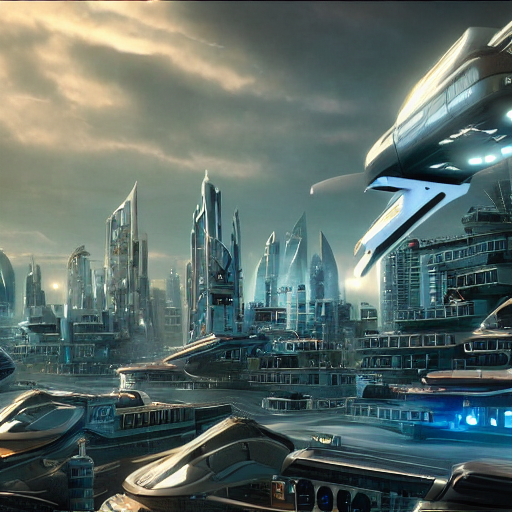

✅ Image saved!


In [5]:
image_agent("a futuristic city with flying cars")

Final Prompt: lego batman, ultra detailed, 4k, cinematic lighting


  0%|          | 0/50 [00:00<?, ?it/s]

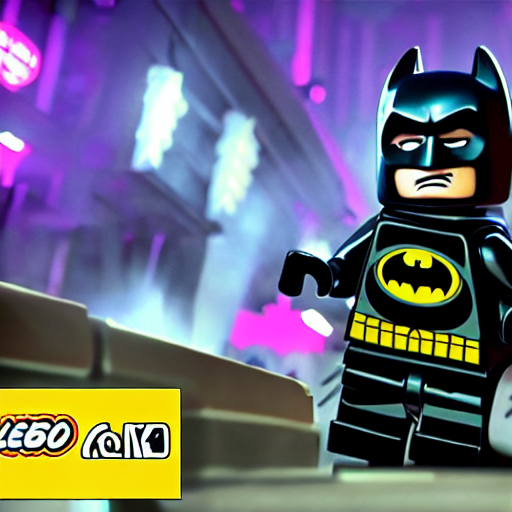

✅ Image saved!


In [8]:
image_agent("lego batman")